# PLOTTING ORBITS

Here, I used Newton's law of Gravitation and Euler's numerical integration to calculate and plot the instantaneos velocity and position of the planet at a particular time t.

While I understand that Euler's method is not the most accurate for this purpose, because the error accumulates in one direction over time, I'm still working on implementing better models like 4th order Runge Kutta or leapfrog (which tries to oscillate error around zero)

I'm using Earth and Sun currently, but I plan on using data from Nasa's Exoplanet Archive to plot orbits of exoplanets.

## Notes while coding this:
I started with Euler’s method even though I know it’s not ideal because I wanted to understand how numerical integration actually behaves.

I noticed that the orbit slowly drifts, which makes sense because Euler accumulates error in one direction. I’m planning to try leapfrog or RK4 next to see how stability changes.

I also used the vis-viva equation to get initial velocity, had to read up a bit to understand where it comes from.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
G = 6.67408e-11

In [ ]:
M_star = 1.9891e+30 #kg      #mass of Sun for now
M_planet = 5.9722e+24 #kg    #mass of Earth for now
e = 0.0167                   #eccentricity
a = 1.496e+11 #m              #semi major axis

In [ ]:
#T^2 = 4(pi^2)(r^3) / GM

T_estimate = (4*(math.pi**2)*(a**3)/(G*M_star))**(0.5)
print("Estimated time period (in days):", T_estimate/(60*60*24))

dt = T_estimate / 10000     #time step (any ratio is fine, taking 10000 first to check time python takes to execuet)

Estimated time period (in days): 365.2073450064896


In [ ]:
#initial conditrions

r_peri = a*(1-e)      #periapsis distance (shortest distamce forom star). using as initial position
pos= np.array([r_peri,0])      #coorinndate in x,y (shortest end point)

The velocity v of a planet revolving around a star in an elliptical orbit is
#determined by the Vis-Viva equation, which links the speed to the instantaneous distance between the
#bodies and the size of the orbit

# v = √(GM((2/r)-(1/a))

init_vel_magnitude = math.sqrt(G * M_star*((2/r_peri) - (1/a)))      #just the magnitude
vel = np.array([0,init_vel_magnitude])          #direction for initial velocity (points directly upwards, posiitve y)

print("Initial position:",pos)
print("Initial velocity:",vel)

Initial position: [1.4710168e+11 0.0000000e+00]
Initial velocity: [    0.        30290.8603096]


In [ ]:
def calc_acceleration(pos):
  r = (pos[0]**2 + pos[1]**2)**(0.5)
  return (-G * M_star * pos / r**3)

In [ ]:
n_orbits = 5        #number of orbits (to make sure it converges)
n_steps = (T_estimate/dt)*n_orbits

In [ ]:
positions=[]    #empty list to plot later, using list to make operations easier. will convert to array after

for i in range(int(n_steps)):
  acc = calc_acceleration(pos)

  #using euler numerical integration as fill in, will write function for leapfrog later

  vel = vel + acc*dt    #v=u+at basically
  pos = pos + vel*dt
  positions.append(pos.copy())       #lists are stored as refernces so just pos would change every time pos is updated

positions = np.array(positions)

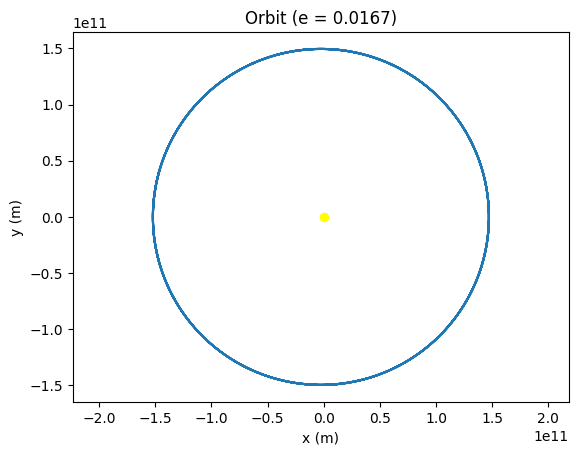

In [ ]:
#plotting path
plt.plot(positions[:,0],positions[:,1])

#plotting sun at focus
plt.plot(0,0, color='yellow',marker='.',markersize=12)

plt.axis('equal')      #to make axes scales equal bc otherwise scales might get stretcged out, figure wont look right
plt.title(f'Orbit (e = {e})')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.show()